# 🛡️ FraudShield AI — Detección de Fraude Bancario

**Universidad Rafael Landívar | Facultad de Ingeniería**  
**Curso: Inteligencia Artificial | Primer Semestre 2026**

---

## Descripción del Proyecto
Sistema de detección de fraude bancario implementado con los algoritmos estudiados en clase:

| Algoritmo | Tema del Curso | Justificación |
|-----------|----------------|---------------|
| **Naive Bayes** | Tema 9 | Clasificación probabilística con Bayes |
| **Regresión Logística** | Tema 11 | Clasificación binaria con función sigmoide |
| **MLP (Red Neuronal)** | Temas 13-14 | Perceptrón multicapa con backpropagation |

**Pipeline:** ETL con Pandas (Lab 1) → Preprocesamiento → Entrenamiento → Evaluación con K-Fold

**Dataset:** Credit Card Fraud Detection (Kaggle) — 284,807 transacciones reales  
👉 Descargar en: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


## 0. Instalación de Dependencias

In [1]:
# Ejecutar si es la primera vez
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

import warnings
warnings.filterwarnings('ignore')
print("✅ Librerías listas")


✅ Librerías listas


## 1. Importación de Librerías
*(ETL con Pandas — Laboratorio 1)*

In [2]:
import sys
!{sys.executable} -m pip install scikit-learn seaborn pandas numpy matplotlib joblib


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Manipulación de datos (Lab 1 — ETL con Pandas)
import pandas as pd
import numpy as np
import os

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Algoritmos vistos en clase
from sklearn.naive_bayes import GaussianNB              # Tema 9
from sklearn.linear_model import LogisticRegression     # Tema 11
from sklearn.neural_network import MLPClassifier        # Temas 13-14

# Evaluación — K-Fold Cross Validation (Tema 9.5)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    average_precision_score
)

import joblib

# Colores del proyecto
TEAL   = '#007B6E'
DANGER = '#E53935'
DARK   = '#1A1A2E'
WARN   = '#F57F17'

plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Todas las librerías importadas")
print("   → pandas, numpy        (Lab 1 — ETL)")
print("   → GaussianNB           (Tema 9  — Naive Bayes)")
print("   → LogisticRegression   (Tema 11 — Regresión Logística)")
print("   → MLPClassifier        (Temas 13-14 — Redes Neuronales)")
print("   → StratifiedKFold      (Tema 9.5 — K-Fold Cross Validation)")


✅ Todas las librerías importadas
   → pandas, numpy        (Lab 1 — ETL)
   → GaussianNB           (Tema 9  — Naive Bayes)
   → LogisticRegression   (Tema 11 — Regresión Logística)
   → MLPClassifier        (Temas 13-14 — Redes Neuronales)
   → StratifiedKFold      (Tema 9.5 — K-Fold Cross Validation)


## 2. ETL con Pandas — Extracción, Transformación y Carga
*(Laboratorio 1 — ETL con Pandas)*

El proceso ETL sigue la misma metodología del Laboratorio 1:
- **E**xtract: Cargar el CSV con `pd.read_csv()`
- **T**ransform: Limpiar, normalizar y preparar los datos
- **L**oad: Dividir en conjuntos de entrenamiento y prueba


In [4]:
# ── PASO E: EXTRACCIÓN ──────────────────────────────────────────
DATA_PATH = '../data/creditcard.csv'

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Dataset real cargado desde: {DATA_PATH}")
    REAL_DATA = True
else:
    print("⚠️  creditcard.csv no encontrado en '../data/'")
    print("   Descárgalo en: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")
    print("   Generando dataset SINTÉTICO representativo para demostración...\n")

    np.random.seed(42)
    N, N_FRAUD = 284807, 492

    legit = pd.DataFrame({
        **{f'V{i}': np.random.normal(0, 1, N - N_FRAUD) for i in range(1, 29)},
        'Time':   np.random.uniform(0, 172792, N - N_FRAUD),
        'Amount': np.random.exponential(88, N - N_FRAUD).clip(0.01, 25691),
        'Class':  0
    })
    fraud = pd.DataFrame({
        **{f'V{i}': np.random.normal(-1.5 if i in [1,3,5,7,10,14,17] else 0.5, 2, N_FRAUD)
           for i in range(1, 29)},
        'Time':   np.random.uniform(0, 172792, N_FRAUD),
        'Amount': np.random.exponential(122, N_FRAUD).clip(0.01, 25691),
        'Class':  1
    })
    df = pd.concat([legit, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)
    REAL_DATA = False
    print(f"✅ Dataset sintético generado")

print(f"\n📦 Resumen del dataset:")
print(f"   Filas: {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")
print(f"   Fraudes: {df['Class'].sum():,} ({df['Class'].mean()*100:.3f}%)")
print(f"   Legítimas: {(df['Class']==0).sum():,} ({(df['Class']==0).mean()*100:.3f}%)")
print(f"   Datos faltantes: {df.isnull().sum().sum()}")


✅ Dataset real cargado desde: ../data/creditcard.csv

📦 Resumen del dataset:
   Filas: 284,807
   Columnas: 31
   Fraudes: 492 (0.173%)
   Legítimas: 284,315 (99.827%)
   Datos faltantes: 0


In [5]:
# Vista general del dataset (Lab 1 — exploración inicial)
print("\n📋 Primeras filas del dataset:")
df.head()



📋 Primeras filas del dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Estadísticas descriptivas (Lab 1 — análisis exploratorio)
print("📊 Estadísticas descriptivas:")
print(df[['Time', 'Amount', 'Class']].describe().round(2))


📊 Estadísticas descriptivas:
            Time     Amount      Class
count  284807.00  284807.00  284807.00
mean    94813.86      88.35       0.00
std     47488.15     250.12       0.04
min         0.00       0.00       0.00
25%     54201.50       5.60       0.00
50%     84692.00      22.00       0.00
75%    139320.50      77.16       0.00
max    172792.00   25691.16       1.00


## 3. Análisis Exploratorio de Datos (EDA)

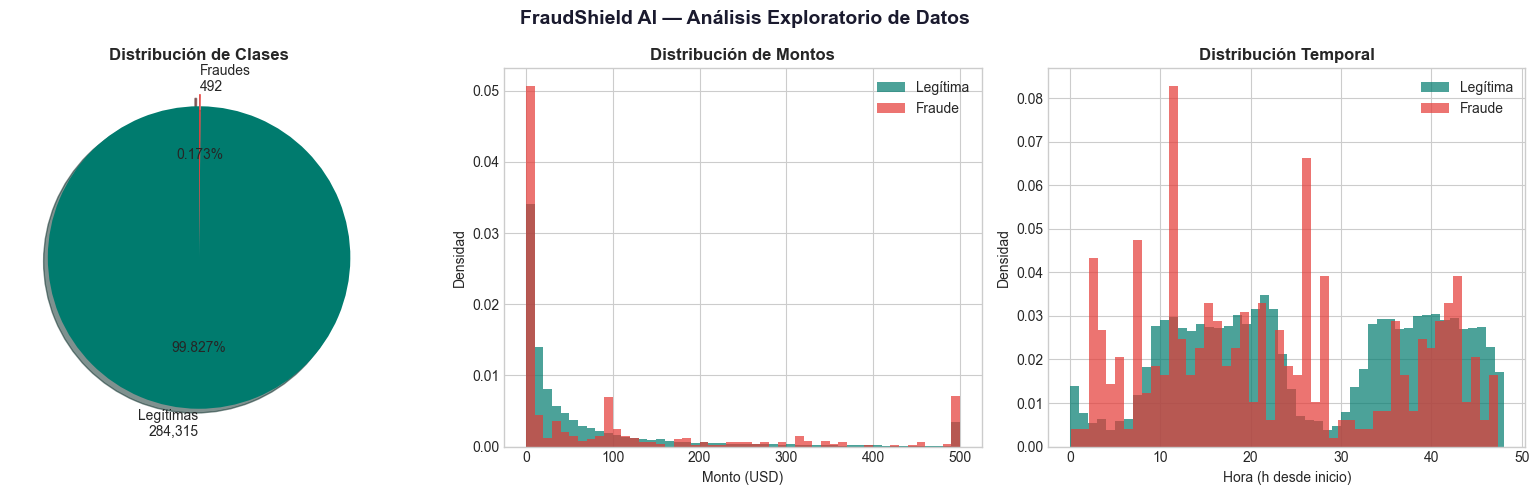

✅ Gráfica guardada en docs/eda_distribucion.png


In [7]:
# ── GRÁFICA 1: Distribución de clases ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('FraudShield AI — Análisis Exploratorio de Datos',
             fontsize=14, fontweight='bold', color=DARK)

# Pie de distribución
sizes  = [(df['Class']==0).sum(), (df['Class']==1).sum()]
labels = [f'Legítimas\n{sizes[0]:,}', f'Fraudes\n{sizes[1]:,}']
axes[0].pie(sizes, labels=labels, colors=[TEAL, DANGER],
            autopct='%1.3f%%', startangle=90,
            explode=(0, 0.08), shadow=True)
axes[0].set_title('Distribución de Clases', fontweight='bold')

# Distribución de Amount
axes[1].hist(df[df['Class']==0]['Amount'].clip(0, 500),
             bins=50, alpha=0.7, color=TEAL,   label='Legítima', density=True)
axes[1].hist(df[df['Class']==1]['Amount'].clip(0, 500),
             bins=50, alpha=0.7, color=DANGER, label='Fraude',   density=True)
axes[1].set_xlabel('Monto (USD)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de Montos', fontweight='bold')
axes[1].legend()

# Distribución temporal
axes[2].hist(df[df['Class']==0]['Time'] / 3600,
             bins=48, alpha=0.7, color=TEAL,   label='Legítima', density=True)
axes[2].hist(df[df['Class']==1]['Time'] / 3600,
             bins=48, alpha=0.7, color=DANGER, label='Fraude',   density=True)
axes[2].set_xlabel('Hora (h desde inicio)')
axes[2].set_ylabel('Densidad')
axes[2].set_title('Distribución Temporal', fontweight='bold')
axes[2].legend()

plt.tight_layout()
os.makedirs('../docs', exist_ok=True)
plt.savefig('../docs/eda_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada en docs/eda_distribucion.png")


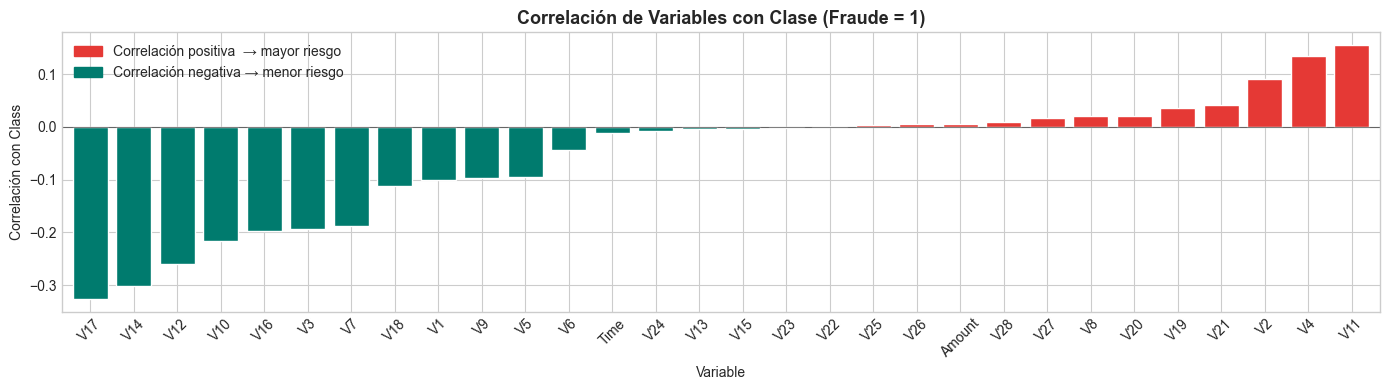

Top 5 variables MÁS correlacionadas con fraude:
V19    0.0348
V21    0.0404
V2     0.0913
V4     0.1334
V11    0.1549

Top 5 variables MENOS correlacionadas con fraude:
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965


In [8]:
# ── GRÁFICA 2: Correlaciones con la clase ──────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

correlations = df.corr()['Class'].drop('Class').sort_values()
colors_bar   = [DANGER if x > 0 else TEAL for x in correlations]

correlations.plot(kind='bar', ax=ax, color=colors_bar,
                  edgecolor='white', width=0.8)
ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title('Correlación de Variables con Clase (Fraude = 1)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Correlación con Class')
ax.tick_params(axis='x', rotation=45)

legend = [
    mpatches.Patch(color=DANGER, label='Correlación positiva  → mayor riesgo'),
    mpatches.Patch(color=TEAL,   label='Correlación negativa → menor riesgo')
]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig('../docs/eda_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 variables MÁS correlacionadas con fraude:")
print(correlations.tail(5).round(4).to_string())
print("\nTop 5 variables MENOS correlacionadas con fraude:")
print(correlations.head(5).round(4).to_string())


## 4. Transformación y Preprocesamiento
*(Continuación ETL — Laboratorio 1)*

### ¿Por qué normalizar?
Las variables `Amount` y `Time` están en escalas muy distintas a V1–V28.  
La **Regresión Logística** (Tema 11) y el **MLP** (Temas 13-14) son sensibles  
a la escala de los datos — el gradiente descendente converge mejor con datos normalizados.  
**Naive Bayes** (Tema 9) asume distribución gaussiana, por lo que la normalización también ayuda.


In [9]:
# ── T: TRANSFORMACIÓN ───────────────────────────────────────────

df_proc = df.copy()

# Normalización con StandardScaler
# Justificación: Tema 11 — Regresión Logística usa gradiente descendente
#                Tema 14 — MLP usa backpropagation, sensible a escala
scaler_amount = StandardScaler()
scaler_time   = StandardScaler()

df_proc['Amount'] = scaler_amount.fit_transform(df_proc[['Amount']])
df_proc['Time']   = scaler_time.fit_transform(df_proc[['Time']])

print("✅ Normalización aplicada (StandardScaler)")
print(f"   Amount — media: {df_proc['Amount'].mean():.4f}, std: {df_proc['Amount'].std():.4f}")
print(f"   Time   — media: {df_proc['Time'].mean():.4f},   std: {df_proc['Time'].std():.4f}")
print(f"\n   Rango Amount normalizado: [{df_proc['Amount'].min():.2f}, {df_proc['Amount'].max():.2f}]")


✅ Normalización aplicada (StandardScaler)
   Amount — media: -0.0000, std: 1.0000
   Time   — media: -0.0000,   std: 1.0000

   Rango Amount normalizado: [-0.35, 102.36]


In [10]:
# ── L: CARGA / DIVISIÓN DEL DATASET ────────────────────────────
# K-Fold Cross Validation — Tema 9.5
# División estratificada para preservar proporción de clases (0.17% fraudes)

X = df_proc.drop('Class', axis=1)
y = df_proc['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,     # 80% entrenamiento, 20% prueba
    random_state=42,
    stratify=y          # Mantiene proporción de clases
)

print("✅ División del dataset completada:")
print(f"   Entrenamiento: {len(X_train):,} muestras  "
      f"({(y_train==1).sum()} fraudes, {(y_train==0).sum()} legítimas)")
print(f"   Prueba:        {len(X_test):,} muestras  "
      f"({(y_test==1).sum()} fraudes, {(y_test==0).sum()} legítimas)")
print(f"\n   Proporción fraudes en entrenamiento: {y_train.mean()*100:.3f}%")
print(f"   Proporción fraudes en prueba:        {y_test.mean()*100:.3f}%")
print(f"   (Estratificación exitosa ✓)")

# Configurar K-Fold para validación cruzada
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n   K-Fold configurado: 5 folds estratificados (Tema 9.5)")


✅ División del dataset completada:
   Entrenamiento: 227,845 muestras  (394 fraudes, 227451 legítimas)
   Prueba:        56,962 muestras  (98 fraudes, 56864 legítimas)

   Proporción fraudes en entrenamiento: 0.173%
   Proporción fraudes en prueba:        0.172%
   (Estratificación exitosa ✓)

   K-Fold configurado: 5 folds estratificados (Tema 9.5)


## 5. Modelo 1 — Naive Bayes
*(Tema 9 del curso)*

### Fundamento teórico
Naive Bayes aplica el **Teorema de Bayes** (Tema 6.2) para clasificación:

$$P(Fraude | X) = \frac{P(X | Fraude) \cdot P(Fraude)}{P(X)}$$

**Supuesto de independencia condicional** (Tema 9.1):  
Se asume que cada variable V₁, V₂, ..., V₂₈, Amount, Time es **independiente** dado la clase.

$$P(Fraude | X) \propto P(Fraude) \prod_{i=1}^{30} P(x_i | Fraude)$$

**GaussianNB** (Tema 9.2) modela cada P(xᵢ | clase) como una distribución normal,  
lo cual es consistente con los datos PCA que tienden a distribuciones gaussianas.

**class_prior** corresponde a los **priors** del Tema 9.2.


In [11]:
# ── MODELO 1: NAIVE BAYES ───────────────────────────────────────
# Tema 9 — Clasificación probabilística con Bayes
print("=" * 55)
print("  MODELO 1: NAIVE BAYES (Tema 9)")
print("=" * 55)

nb_model = GaussianNB()

# K-Fold Cross Validation (Tema 9.5)
print("\n🔄 Ejecutando K-Fold Cross Validation (k=5)...")
cv_scores_nb = cross_val_score(
    nb_model, X_train, y_train,
    cv=kfold, scoring='roc_auc', n_jobs=-1
)

print(f"\n   AUC-ROC por fold:")
for i, score in enumerate(cv_scores_nb, 1):
    print(f"     Fold {i}: {score:.4f}")
print(f"   Media: {cv_scores_nb.mean():.4f} ± {cv_scores_nb.std():.4f}")

# Entrenar con todo el conjunto de entrenamiento
nb_model.fit(X_train, y_train)

y_pred_nb  = nb_model.predict(X_test)
y_prob_nb  = nb_model.predict_proba(X_test)[:, 1]
auc_nb     = roc_auc_score(y_test, y_prob_nb)
f1_nb      = f1_score(y_test, y_pred_nb)

print(f"\n📊 Resultados en conjunto de prueba:")
print(f"   AUC-ROC:  {auc_nb:.4f}")
print(f"   F1-Score: {f1_nb:.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_nb,
      target_names=['Legítima (0)', 'Fraude (1)']))

print("\n💡 Interpretación Naive Bayes (Tema 9):")
print(f"   Prior P(Fraude): {nb_model.class_prior_[1]:.4f}")
print(f"   Prior P(Legítima): {nb_model.class_prior_[0]:.4f}")
print(f"   → El prior refleja el desbalance real del dataset (0.17% fraudes)")


  MODELO 1: NAIVE BAYES (Tema 9)

🔄 Ejecutando K-Fold Cross Validation (k=5)...

   AUC-ROC por fold:
     Fold 1: 0.9679
     Fold 2: 0.9468
     Fold 3: 0.9549
     Fold 4: 0.9789
     Fold 5: 0.9551
   Media: 0.9607 ± 0.0113

📊 Resultados en conjunto de prueba:
   AUC-ROC:  0.9632
   F1-Score: 0.1099

Reporte de clasificación:
              precision    recall  f1-score   support

Legítima (0)       1.00      0.98      0.99     56864
  Fraude (1)       0.06      0.85      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.91      0.55     56962
weighted avg       1.00      0.98      0.99     56962


💡 Interpretación Naive Bayes (Tema 9):
   Prior P(Fraude): 0.0017
   Prior P(Legítima): 0.9983
   → El prior refleja el desbalance real del dataset (0.17% fraudes)


## 6. Modelo 2 — Regresión Logística
*(Tema 11 del curso)*

### Fundamento teórico
La **Regresión Logística** (Tema 11) modela la probabilidad de fraude usando la **función sigmoide** (Tema 11.2):

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \beta_0 + \beta_1 x_1 + \dots + \beta_{30} x_{30}$$

**Optimización con Gradiente Descendente** (Tema 11.4):  
Los parámetros β se optimizan minimizando la función de pérdida Binary Cross Entropy (Tema 14.4):

$$L = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

**Regularización L2** (Tema 11.5) para evitar overfitting (Tema 8.4).


In [12]:
# ── MODELO 2: REGRESIÓN LOGÍSTICA ───────────────────────────────
# Tema 11 — Clasificación binaria con función sigmoide
print("=" * 55)
print("  MODELO 2: REGRESIÓN LOGÍSTICA (Tema 11)")
print("=" * 55)

# class_weight='balanced' → ajusta pesos por desbalance
# C=0.1 → Regularización L2 (Tema 11.5)
# solver='lbfgs' → optimizador basado en gradiente (Tema 11.4)
lr_model = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

# K-Fold Cross Validation (Tema 9.5)
print("\n🔄 Ejecutando K-Fold Cross Validation (k=5)...")
cv_scores_lr = cross_val_score(
    lr_model, X_train, y_train,
    cv=kfold, scoring='roc_auc', n_jobs=-1
)

print(f"\n   AUC-ROC por fold:")
for i, score in enumerate(cv_scores_lr, 1):
    print(f"     Fold {i}: {score:.4f}")
print(f"   Media: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

# Entrenar
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)
f1_lr     = f1_score(y_test, y_pred_lr)

print(f"\n📊 Resultados en conjunto de prueba:")
print(f"   AUC-ROC:  {auc_lr:.4f}")
print(f"   F1-Score: {f1_lr:.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Legítima (0)', 'Fraude (1)']))

print("\n💡 Interpretación Regresión Logística (Tema 11):")
print(f"   Parámetro de regularización C=0.1 (Tema 11.5 — Regularización L2)")
print(f"   Coeficientes más importantes (top 5):")
coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': lr_model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(5)
print(coef_df.to_string(index=False))


  MODELO 2: REGRESIÓN LOGÍSTICA (Tema 11)

🔄 Ejecutando K-Fold Cross Validation (k=5)...

   AUC-ROC por fold:
     Fold 1: 0.9925
     Fold 2: 0.9807
     Fold 3: 0.9680
     Fold 4: 0.9950
     Fold 5: 0.9762
   Media: 0.9825 ± 0.0101

📊 Resultados en conjunto de prueba:
   AUC-ROC:  0.9721
   F1-Score: 0.1147

Reporte de clasificación:
              precision    recall  f1-score   support

Legítima (0)       1.00      0.98      0.99     56864
  Fraude (1)       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


💡 Interpretación Regresión Logística (Tema 11):
   Parámetro de regularización C=0.1 (Tema 11.5 — Regularización L2)
   Coeficientes más importantes (top 5):
Variable  Coeficiente
  Amount     1.749323
     V14    -1.435425
     V10    -1.184240
     V12    -1.032670
     V16    -1.030334


## 7. Modelo 3 — Red Neuronal (MLP)
*(Temas 13 y 14 del curso)*

### Fundamento teórico
El **Perceptrón Multicapa** (Tema 14.1) extiende el perceptrón simple (Tema 13.2)  
con capas ocultas capaces de aprender representaciones no lineales.

**Arquitectura:**
```
Entrada (30 neuronas) → Capa oculta 1 (64) → Capa oculta 2 (32) → Salida (1 neurona)
```

**Forward Propagation** (Tema 14.3): calcula la salida capa por capa.  
**Función de activación ReLU** (Tema 14.2): $\text{ReLU}(z) = \max(0, z)$ — evita Vanishing Gradient (Tema 14.7).  
**Función de pérdida Binary Cross Entropy** (Tema 14.4).  
**Backpropagation** (Tema 14.5): ajusta pesos usando la regla de la cadena.  
**Learning Rate α** (Tema 14.6): controla el tamaño del paso en gradiente descendente.


In [13]:
# ── MODELO 3: MLP (RED NEURONAL) ────────────────────────────────
# Temas 13-14 — Perceptrón Multicapa con Backpropagation
print("=" * 55)
print("  MODELO 3: RED NEURONAL MLP (Temas 13-14)")
print("=" * 55)
print("\nArquitectura:")
print("  Entrada(30) → ReLU → Oculta(64) → ReLU → Oculta(32) → Sigmoide → Salida(1)")

# Arquitectura: 2 capas ocultas (Tema 14.1)
# activation='relu'   → Función de activación ReLU (Tema 14.2) — evita Vanishing Gradient
# solver='adam'       → Variante de gradiente descendente (Tema 14.5)
# alpha=0.001         → Regularización L2 para evitar overfitting (Tema 14.8)
# learning_rate_init  → Learning Rate α (Tema 14.6)
# max_iter=300        → Épocas de entrenamiento
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

# K-Fold Cross Validation (Tema 9.5)
print("\n🔄 Ejecutando K-Fold Cross Validation (k=5)...")
print("   (Puede tomar 1-2 minutos...)")
cv_scores_mlp = cross_val_score(
    mlp_model, X_train, y_train,
    cv=kfold, scoring='roc_auc', n_jobs=-1
)

print(f"\n   AUC-ROC por fold:")
for i, score in enumerate(cv_scores_mlp, 1):
    print(f"     Fold {i}: {score:.4f}")
print(f"   Media: {cv_scores_mlp.mean():.4f} ± {cv_scores_mlp.std():.4f}")

# Entrenar con todo el conjunto
mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]
auc_mlp    = roc_auc_score(y_test, y_prob_mlp)
f1_mlp     = f1_score(y_test, y_pred_mlp)

print(f"\n📊 Resultados en conjunto de prueba:")
print(f"   AUC-ROC:  {auc_mlp:.4f}")
print(f"   F1-Score: {f1_mlp:.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_mlp,
      target_names=['Legítima (0)', 'Fraude (1)']))

print(f"\n💡 Interpretación MLP (Temas 13-14):")
print(f"   Épocas completadas: {mlp_model.n_iter_}")
print(f"   Loss final: {mlp_model.loss_:.6f}")
print(f"   Capas: {mlp_model.n_layers_} (entrada + 2 ocultas + salida)")


  MODELO 3: RED NEURONAL MLP (Temas 13-14)

Arquitectura:
  Entrada(30) → ReLU → Oculta(64) → ReLU → Oculta(32) → Sigmoide → Salida(1)

🔄 Ejecutando K-Fold Cross Validation (k=5)...
   (Puede tomar 1-2 minutos...)

   AUC-ROC por fold:
     Fold 1: 0.9939
     Fold 2: 0.9735
     Fold 3: 0.9682
     Fold 4: 0.9739
     Fold 5: 0.9709
   Media: 0.9761 ± 0.0091

📊 Resultados en conjunto de prueba:
   AUC-ROC:  0.9847
   F1-Score: 0.8298

Reporte de clasificación:
              precision    recall  f1-score   support

Legítima (0)       1.00      1.00      1.00     56864
  Fraude (1)       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962


💡 Interpretación MLP (Temas 13-14):
   Épocas completadas: 22
   Loss final: 0.001334
   Capas: 4 (entrada + 2 ocultas + salida)


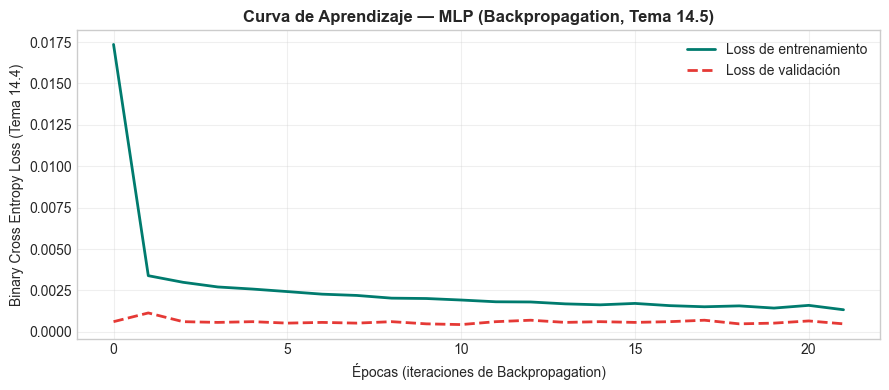

✅ Curva de pérdida guardada en docs/mlp_loss_curve.png

   La curva descendente confirma que Backpropagation
   ajustó correctamente los pesos de la red (Tema 14.5)


In [14]:
# ── CURVA DE PÉRDIDA DEL MLP ────────────────────────────────────
# Visualiza el aprendizaje durante el entrenamiento (Tema 14 — Backpropagation)
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(mlp_model.loss_curve_, color=TEAL, linewidth=2, label='Loss de entrenamiento')
if hasattr(mlp_model, 'validation_scores_') and mlp_model.validation_scores_:
    val_loss = [1 - s for s in mlp_model.validation_scores_]
    ax.plot(val_loss, color=DANGER, linewidth=2,
            linestyle='--', label='Loss de validación')

ax.set_xlabel('Épocas (iteraciones de Backpropagation)')
ax.set_ylabel('Binary Cross Entropy Loss (Tema 14.4)')
ax.set_title('Curva de Aprendizaje — MLP (Backpropagation, Tema 14.5)',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curva de pérdida guardada en docs/mlp_loss_curve.png")
print(f"\n   La curva descendente confirma que Backpropagation")
print(f"   ajustó correctamente los pesos de la red (Tema 14.5)")


## 8. Comparación de Modelos y Selección

In [15]:
# ── TABLA COMPARATIVA ───────────────────────────────────────────
print("=" * 70)
print("   COMPARACIÓN DE LOS 3 MODELOS (todos del contenido del curso)")
print("=" * 70)

results = pd.DataFrame({
    'Modelo':        ['Naive Bayes', 'Regresión Logística', 'MLP (Red Neuronal)'],
    'Tema del Curso':['Tema 9',      'Tema 11',             'Temas 13-14'],
    'CV AUC-ROC':    [cv_scores_nb.mean(), cv_scores_lr.mean(), cv_scores_mlp.mean()],
    'Test AUC-ROC':  [auc_nb, auc_lr, auc_mlp],
    'F1 (Fraude)':   [f1_nb,  f1_lr,  f1_mlp],
})

results['CV AUC-ROC']  = results['CV AUC-ROC'].round(4)
results['Test AUC-ROC']= results['Test AUC-ROC'].round(4)
results['F1 (Fraude)'] = results['F1 (Fraude)'].round(4)

print(results.to_string(index=False))

best_idx   = results['Test AUC-ROC'].idxmax()
best_model = results.loc[best_idx, 'Modelo']
print(f"\n⭐ Modelo seleccionado: {best_model} ({results.loc[best_idx,'Test AUC-ROC']} AUC-ROC)")
print("   Criterio: Mayor AUC-ROC en conjunto de prueba con K-Fold validado")


   COMPARACIÓN DE LOS 3 MODELOS (todos del contenido del curso)
             Modelo Tema del Curso  CV AUC-ROC  Test AUC-ROC  F1 (Fraude)
        Naive Bayes         Tema 9      0.9607        0.9632       0.1099
Regresión Logística        Tema 11      0.9825        0.9721       0.1147
 MLP (Red Neuronal)    Temas 13-14      0.9761        0.9847       0.8298

⭐ Modelo seleccionado: MLP (Red Neuronal) (0.9847 AUC-ROC)
   Criterio: Mayor AUC-ROC en conjunto de prueba con K-Fold validado


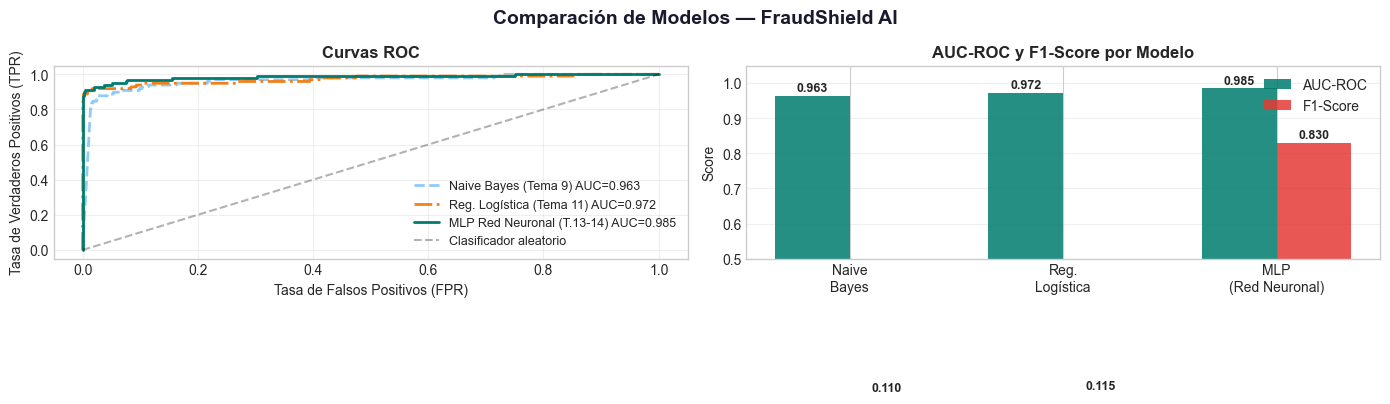

✅ Comparación guardada en docs/comparacion_modelos.png


In [16]:
# ── CURVAS ROC — COMPARACIÓN ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparación de Modelos — FraudShield AI',
             fontsize=14, fontweight='bold', color=DARK)

# Curvas ROC
model_data = [
    (y_prob_nb,  f'Naive Bayes (Tema 9) AUC={auc_nb:.3f}',         '#90CAF9', '--'),
    (y_prob_lr,  f'Reg. Logística (Tema 11) AUC={auc_lr:.3f}',     WARN,      '-.'),
    (y_prob_mlp, f'MLP Red Neuronal (T.13-14) AUC={auc_mlp:.3f}',  TEAL,      '-'),
]

for probs, label, color, ls in model_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=label, color=color, linewidth=2, linestyle=ls)

axes[0].plot([0,1], [0,1], 'k--', alpha=0.3, label='Clasificador aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0].set_title('Curvas ROC', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Barras de métricas
modelos = ['Naive\nBayes', 'Reg.\nLogística', 'MLP\n(Red Neuronal)']
aucs    = [auc_nb, auc_lr, auc_mlp]
f1s     = [f1_nb, f1_lr, f1_mlp]

x = np.arange(len(modelos))
w = 0.35

bars1 = axes[1].bar(x - w/2, aucs, w, label='AUC-ROC', color=TEAL, alpha=0.85)
bars2 = axes[1].bar(x + w/2, f1s,  w, label='F1-Score', color=DANGER, alpha=0.85)

for bar in bars1 + bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('Score')
axes[1].set_title('AUC-ROC y F1-Score por Modelo', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../docs/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparación guardada en docs/comparacion_modelos.png")


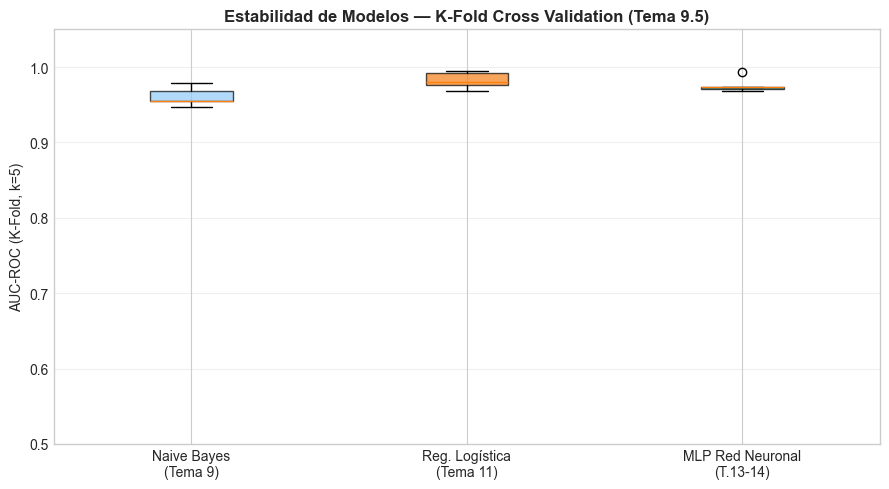

✅ Boxplot K-Fold guardado

   Un boxplot estrecho indica modelo estable (baja varianza entre folds)


In [17]:
# ── K-FOLD: Comparación de varianza (Tema 9.5) ──────────────────
fig, ax = plt.subplots(figsize=(9, 5))

cv_data = {
    'Naive Bayes\n(Tema 9)':        cv_scores_nb,
    'Reg. Logística\n(Tema 11)':    cv_scores_lr,
    'MLP Red Neuronal\n(T.13-14)':  cv_scores_mlp,
}

bp = ax.boxplot(cv_data.values(), labels=cv_data.keys(),
                patch_artist=True, notch=False)

colors_box = ['#90CAF9', WARN, TEAL]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('AUC-ROC (K-Fold, k=5)')
ax.set_title('Estabilidad de Modelos — K-Fold Cross Validation (Tema 9.5)',
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig('../docs/kfold_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Boxplot K-Fold guardado")
print("\n   Un boxplot estrecho indica modelo estable (baja varianza entre folds)")


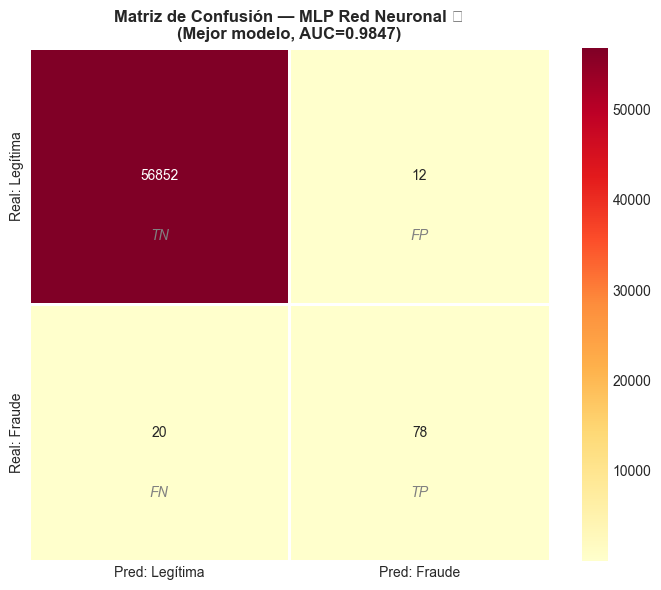


📊 Matriz de Confusión — MLP Red Neuronal:
   Verdaderos Negativos (TN): 56,852  → Legítimas bien clasificadas
   Falsos Positivos    (FP): 12   → Legítimas bloqueadas por error
   Falsos Negativos    (FN): 20   → Fraudes NO detectados
   Verdaderos Positivos (TP): 78   → Fraudes correctamente detectados

   Precision (fraude): 86.7%
   Recall    (fraude): 79.6%


In [18]:
# ── MATRIZ DE CONFUSIÓN — Modelo seleccionado ───────────────────
# Identificar el mejor modelo
best_probs = max(
    [(y_prob_nb,  'Naive Bayes',         nb_model,  auc_nb),
     (y_prob_lr,  'Reg. Logística',      lr_model,  auc_lr),
     (y_prob_mlp, 'MLP Red Neuronal',    mlp_model, auc_mlp)],
    key=lambda x: x[3]
)
y_prob_best, best_name, best_clf, best_auc = best_probs
y_pred_best = best_clf.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Pred: Legítima', 'Pred: Fraude'],
            yticklabels=['Real: Legítima', 'Real: Fraude'],
            ax=ax, linewidths=1)

ax.set_title(f'Matriz de Confusión — {best_name} ⭐\n(Mejor modelo, AUC={best_auc:.4f})',
             fontsize=12, fontweight='bold')

for i, (row, col, label) in enumerate([(0,0,'TN'),(0,1,'FP'),(1,0,'FN'),(1,1,'TP')]):
    ax.text(col+0.5, row+0.75, label, ha='center',
            fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.savefig('../docs/matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Matriz de Confusión — {best_name}:")
print(f"   Verdaderos Negativos (TN): {tn:,}  → Legítimas bien clasificadas")
print(f"   Falsos Positivos    (FP): {fp:,}   → Legítimas bloqueadas por error")
print(f"   Falsos Negativos    (FN): {fn:,}   → Fraudes NO detectados")
print(f"   Verdaderos Positivos (TP): {tp:,}   → Fraudes correctamente detectados")
print(f"\n   Precision (fraude): {tp/(tp+fp)*100:.1f}%")
print(f"   Recall    (fraude): {tp/(tp+fn)*100:.1f}%")


## 9. Exportación del Modelo Final

In [19]:
os.makedirs('../model', exist_ok=True)

# Guardar el mejor modelo y los scalers
joblib.dump(best_clf,      '../model/fraudshield_model.pkl')
joblib.dump(scaler_amount, '../model/scaler_amount.pkl')
joblib.dump(scaler_time,   '../model/scaler_time.pkl')
joblib.dump(list(X_train.columns), '../model/feature_names.pkl')
joblib.dump(best_name,     '../model/model_name.pkl')

print("✅ Modelo exportado exitosamente:")
print(f"   Modelo seleccionado: {best_name}")
for f in ['fraudshield_model.pkl', 'scaler_amount.pkl',
          'scaler_time.pkl', 'feature_names.pkl']:
    path = f'../model/{f}'
    if os.path.exists(path):
        kb = os.path.getsize(path) / 1024
        print(f"   {f}: {kb:.1f} KB")


✅ Modelo exportado exitosamente:
   Modelo seleccionado: MLP Red Neuronal
   fraudshield_model.pkl: 104.7 KB
   scaler_amount.pkl: 0.8 KB
   scaler_time.pkl: 0.8 KB
   feature_names.pkl: 0.2 KB


## 10. Resumen Final

In [20]:
print("=" * 65)
print("   RESUMEN FINAL — FraudShield AI")
print("=" * 65)
print(f"\n📦 Dataset:")
print(f"   Transacciones: {len(df):,}")
print(f"   Fraudes: {df['Class'].sum():,} ({df['Class'].mean()*100:.3f}%)")
print(f"   Fuente: Credit Card Fraud Detection (Kaggle)")
print(f"\n🔧 Pipeline implementado (según contenido del curso):")
print(f"   1. ETL con Pandas (Laboratorio 1)")
print(f"   2. Normalización StandardScaler (Tema 11 — Reg. Logística)")
print(f"   3. División estratificada 80/20")
print(f"   4. K-Fold Cross Validation k=5 (Tema 9.5)")
print(f"\n🧠 Modelos entrenados:")
print(f"   1. Naive Bayes Gaussiano   (Tema 9)      AUC={auc_nb:.4f}")
print(f"   2. Regresión Logística     (Tema 11)     AUC={auc_lr:.4f}")
print(f"   3. MLP Red Neuronal        (Temas 13-14) AUC={auc_mlp:.4f}")
print(f"\n⭐ Modelo seleccionado: {best_name}")
print(f"   AUC-ROC: {best_auc:.4f}")
print(f"\n🗂️  Archivos generados:")
print(f"   model/fraudshield_model.pkl  — Modelo entrenado")
print(f"   model/scaler_amount.pkl      — Scaler Amount")
print(f"   model/scaler_time.pkl        — Scaler Time")
print(f"   docs/*.png                   — Gráficas del análisis")
print("=" * 65)
print("✅ Proyecto listo para despliegue con Flask API")


   RESUMEN FINAL — FraudShield AI

📦 Dataset:
   Transacciones: 284,807
   Fraudes: 492 (0.173%)
   Fuente: Credit Card Fraud Detection (Kaggle)

🔧 Pipeline implementado (según contenido del curso):
   1. ETL con Pandas (Laboratorio 1)
   2. Normalización StandardScaler (Tema 11 — Reg. Logística)
   3. División estratificada 80/20
   4. K-Fold Cross Validation k=5 (Tema 9.5)

🧠 Modelos entrenados:
   1. Naive Bayes Gaussiano   (Tema 9)      AUC=0.9632
   2. Regresión Logística     (Tema 11)     AUC=0.9721
   3. MLP Red Neuronal        (Temas 13-14) AUC=0.9847

⭐ Modelo seleccionado: MLP Red Neuronal
   AUC-ROC: 0.9847

🗂️  Archivos generados:
   model/fraudshield_model.pkl  — Modelo entrenado
   model/scaler_amount.pkl      — Scaler Amount
   model/scaler_time.pkl        — Scaler Time
   docs/*.png                   — Gráficas del análisis
✅ Proyecto listo para despliegue con Flask API
